# Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from sklearn.metrics import roc_auc_score
import statsmodels.api as sm

# Data loading

In [2]:
df = pd.read_csv("AirbnbEurope.csv")

# Filling missing values

In [3]:
# Missing values here occur when 'number_of_reviews' is 0, so 0 is factually correct.
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# Ratings are often skewed; the median provides a "typical" score without being pulled by outliers.
df['review_scores_rating'] = df['review_scores_rating'].fillna(df['review_scores_rating'].median())

# Fill bathrooms, bedrooms, beds nulls based on 'accommodates' group median, then global median
df['bathrooms'] = df.groupby('accommodates')['bathrooms'].transform(lambda x: x.fillna(x.median()))
df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].median())

df['bedrooms'] = df.groupby('accommodates')['bedrooms'].transform(lambda x: x.fillna(x.median()))
df['bedrooms'] = df['bedrooms'].fillna(df['bedrooms'].median())

df['beds'] = df.groupby('accommodates')['beds'].transform(lambda x: x.fillna(x.median()))
df['beds'] = df['beds'].fillna(df['beds'].median())

# Deleting rows with missing price
df = df.dropna(subset=['price'])

# Since log_price is a mathematical derivative of price, we recalculate it to ensure consistency.
df['log_price'] = np.log1p(df['price'])

# Fill Host Info (Small number of missing values)
df['host_since'] = df['host_since'].fillna(df['host_since'].mode()[0])
df['host_total_listings_count'] = df['host_total_listings_count'].fillna(df['host_total_listings_count'].median())
df["host_tenure_days"] = df["host_tenure_days"].abs()
df['host_tenure_days'] = df['host_tenure_days'].fillna(df['host_tenure_days'].median())


In [4]:
# inroduce variable distance to city center (calculate distance using latitude and longitude)
# city centers coordinates for distance calculation
cities_coords = {
    'amsterdam': {'latitude': 52.3791, 'longitude': 4.9003}, 
    'athens': {'latitude': 37.9657, 'longitude': 23.7391}, 
    'barselona': {'latitude': 41.3851, 'longitude': 2.1734}, 
    'berlin': {'latitude': 52.52, 'longitude': 13.405}, 
    'copenhagen': {'latitude': 55.6761, 'longitude': 12.5683}, 
    'london': {'latitude': 51.5074, 'longitude': 0.1272}, 
    'prague': {'latitude': 50.0755, 'longitude': 14.4378}, 
    'rome': {'latitude': 41.9029, 'longitude': 12.4964}, 
    'stockholm': {'latitude': 59.3293, 'longitude': 18.0686}, 
    'vienna': {'latitude': 48.2336, 'longitude': 16.4171}
}

# calculate distance from each listing to city center
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in kilometers
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)
    
    a = np.sin(delta_phi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    
    return R * c

distances = []
for index, row in df.iterrows():
    city = row['city']
    if city in cities_coords:
        city_lat = cities_coords[city]['latitude']
        city_lon = cities_coords[city]['longitude']
        distance = haversine_distance(row['latitude'], row['longitude'], city_lat, city_lon)
        distances.append(distance)
    else:
        distances.append(np.nan)  # If city is not in the list, assign NaN

df['distance_to_city_center'] = distances
df['distance_to_city_center'] = df['distance_to_city_center'].fillna(df['distance_to_city_center'].median())

In [5]:
print(df.isnull().sum())

listing_id                   0
host_since                   0
host_is_superhost            0
host_total_listings_count    0
neighbourhood_cleansed       0
latitude                     0
longitude                    0
property_type                0
room_type                    0
accommodates                 0
bathrooms                    0
bedrooms                     0
beds                         0
price                        0
minimum_nights               0
availability_365             0
number_of_reviews            0
review_scores_rating         0
instant_bookable             0
reviews_per_month            0
host_tenure_days             0
occupancy                    0
reviews_last_year            0
city                         0
log_price                    0
distance_to_city_center      0
dtype: int64


# Working with outliers

## Old dataframe (finding outliers)

Number of outliers: 1222


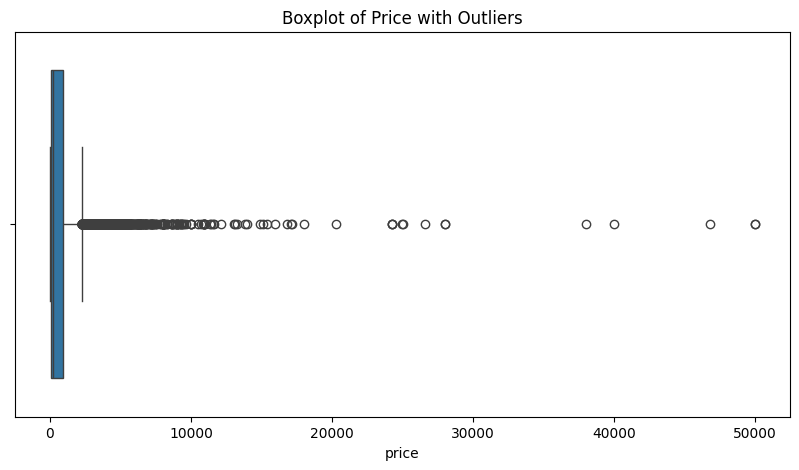

In [6]:
df = df[df['price'] <= 100000].copy()
def get_outliers_info(df, column_name):
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column_name] < lower_bound) | (df[column_name] > upper_bound)]
    
    print(f"Number of outliers: {len(outliers)}")
    
    return outliers, (lower_bound, upper_bound)

price_outliers, bounds = get_outliers_info(df, 'price')

plt.figure(figsize=(10, 5))
sns.boxplot(x=df['price'])
plt.title('Boxplot of Price with Outliers')
plt.show()

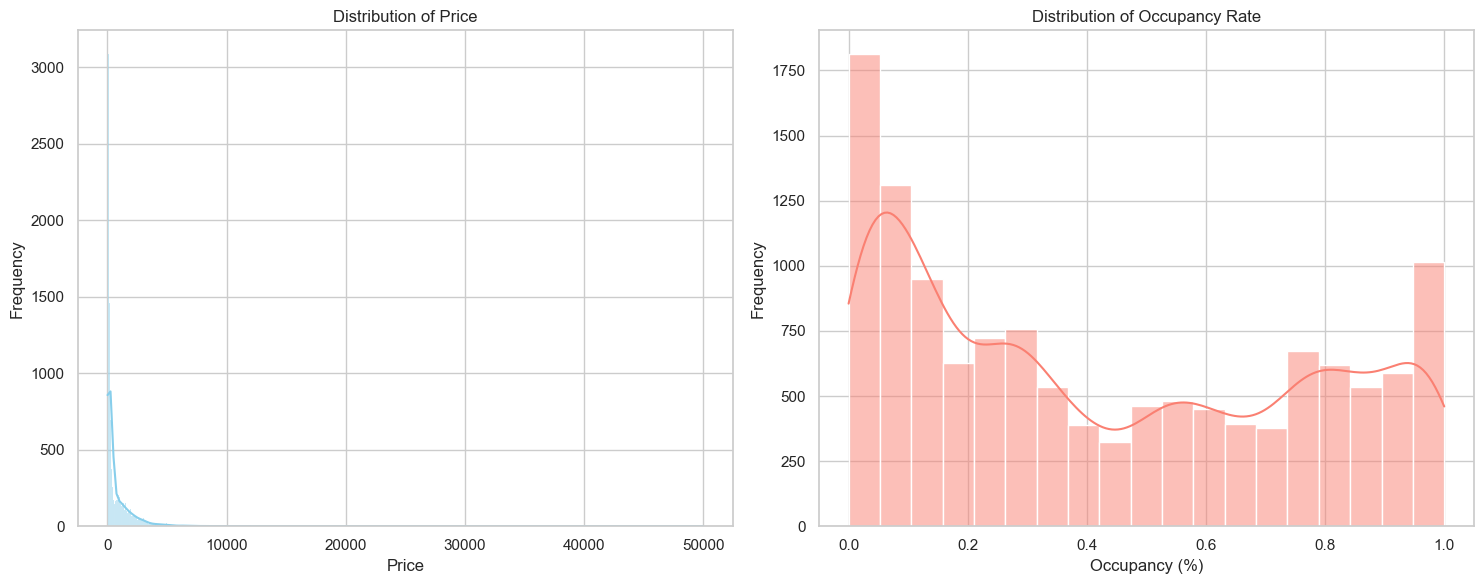

In [7]:
#old_distribution 

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(df['price'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Price')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')

sns.histplot(df['occupancy'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Occupancy Rate')
axes[1].set_xlabel('Occupancy (%)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## New dataframe (deleting outliers)

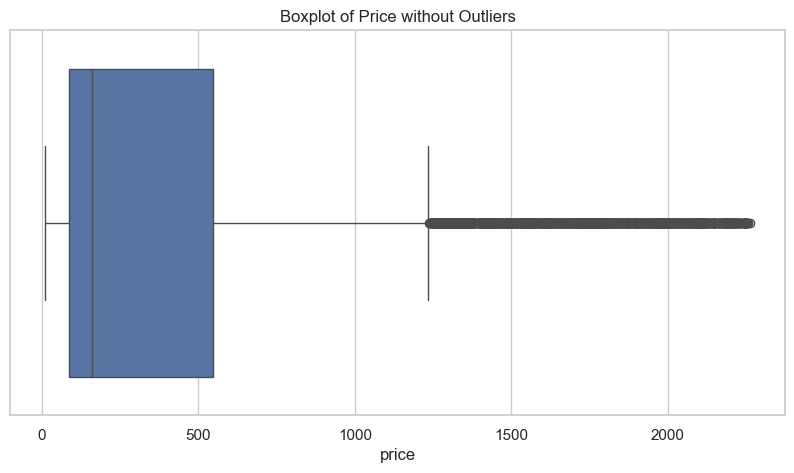

In [8]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)].copy()

df.to_csv('new_one.csv', index=False)

plt.figure(figsize=(10, 5))
sns.boxplot(x=df['price'])
plt.title('Boxplot of Price without Outliers')
plt.show()

# Distribution for price and occupancy

In [9]:
df.to_csv('new_one.csv', index=False)
df = pd.read_csv('new_one.csv')

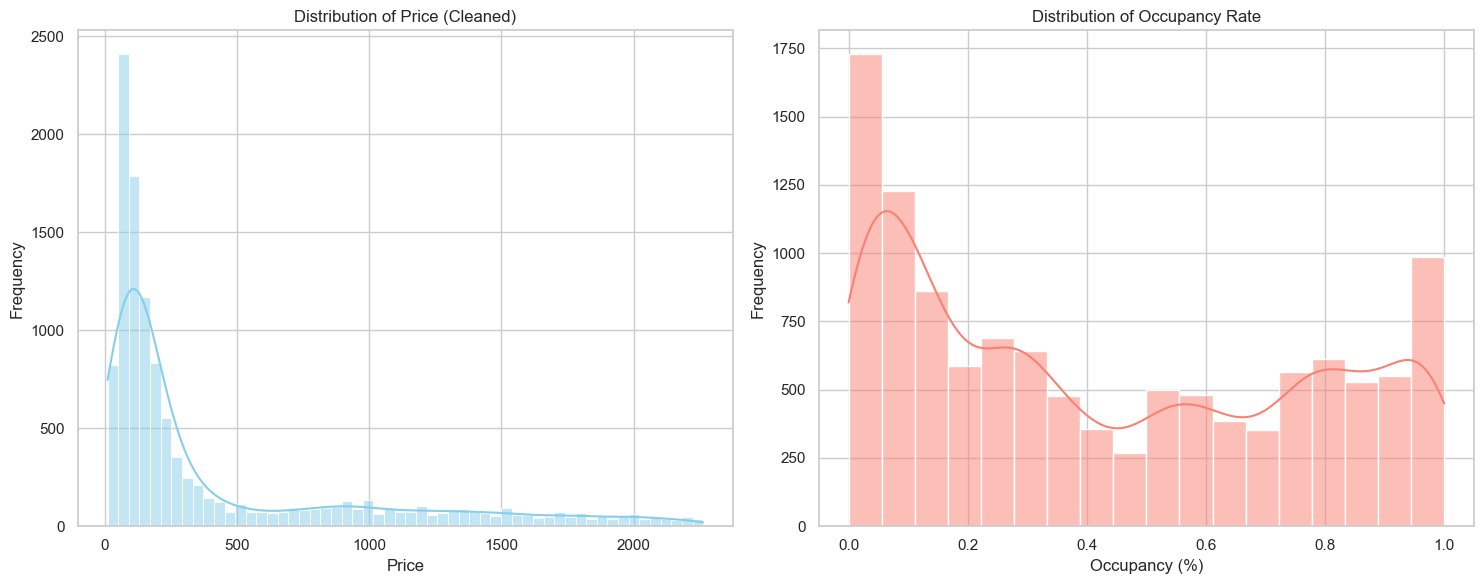

In [10]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(df['price'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Price (Cleaned)')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')

sns.histplot(df['occupancy'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Occupancy Rate')
axes[1].set_xlabel('Occupancy (%)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Mean: 431.363998643378
Median: 159.0
Min: 10.0
Max: 2263.0
Skewness: 1.6627538950931706


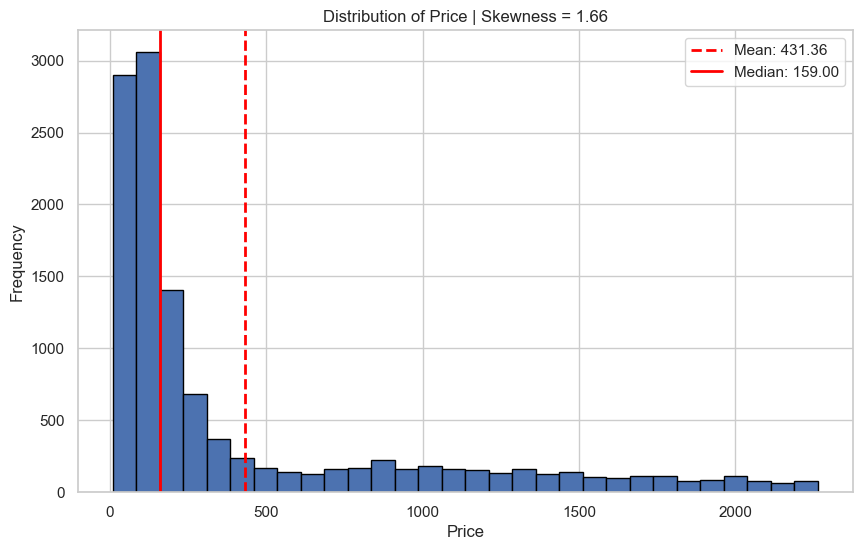

In [11]:
price = df['price']
mean_price = price.mean()
median_price = price.median()
min_price = price.min()
max_price = price.max()
skewness_price = price.skew()

print("Mean:", mean_price)
print("Median:", median_price)
print("Min:", min_price)
print("Max:", max_price)
print("Skewness:", skewness_price)

plt.figure(figsize=(10, 6))
plt.hist(price, bins=30, edgecolor='black')

plt.axvline(mean_price, color = "red", linestyle='--', linewidth=2, label=f'Mean: {mean_price:.2f}')
plt.axvline(median_price, color = "red", linestyle='-', linewidth=2, label=f'Median: {median_price:.2f}')

plt.title(f'Distribution of Price | Skewness = {skewness_price:.2f}')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.legend()
plt.show()

Mean: 0.42896677859001364
Median: 0.3506849315068493
Min: 0.0
Max: 1.0
Skewness: 0.30249958432255003


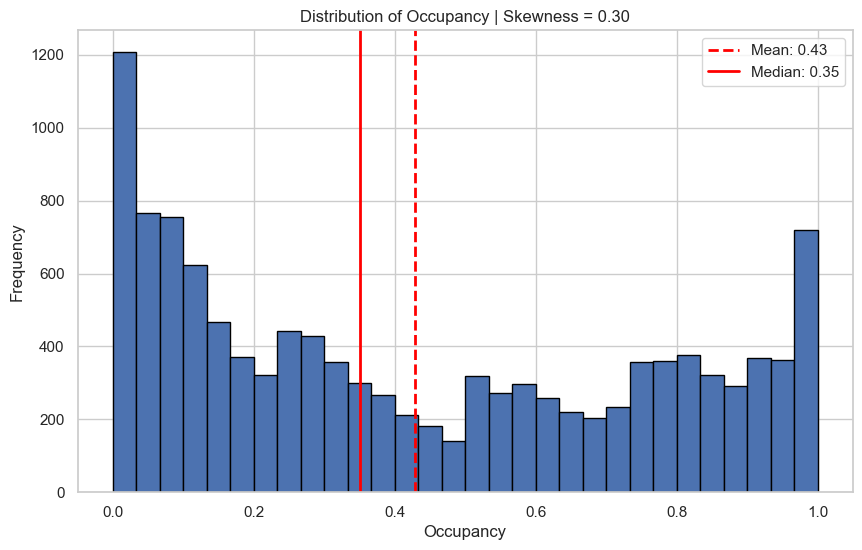

In [12]:
occupancy = df['occupancy']
mean_occupancy = occupancy.mean()
median_occupancy = occupancy.median()
min_occupancy = occupancy.min()
max_occupancy = occupancy.max()
skewness_occupancy = occupancy.skew()

print("Mean:", mean_occupancy)
print("Median:", median_occupancy)
print("Min:", min_occupancy)
print("Max:", max_occupancy)
print("Skewness:", skewness_occupancy)

plt.figure(figsize=(10, 6))
plt.hist(occupancy, bins=30, edgecolor='black')

plt.axvline(mean_occupancy, color = "red", linestyle='--', linewidth=2, label=f'Mean: {mean_occupancy:.2f}')
plt.axvline(median_occupancy, color = "red", linestyle='-', linewidth=2, label=f'Median: {median_occupancy:.2f}')

plt.title(f'Distribution of Occupancy | Skewness = {skewness_occupancy:.2f}')
plt.xlabel('Occupancy')
plt.ylabel('Frequency')
plt.legend()
plt.show()

## Hitmaps

In [13]:

# df = pd.read_csv("new_one.csv")

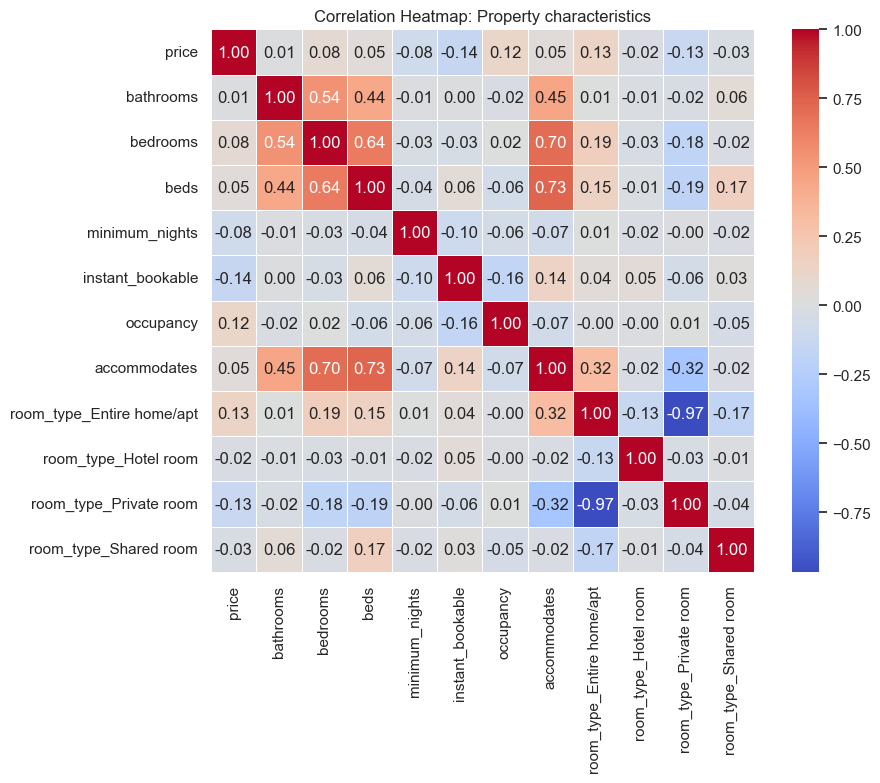

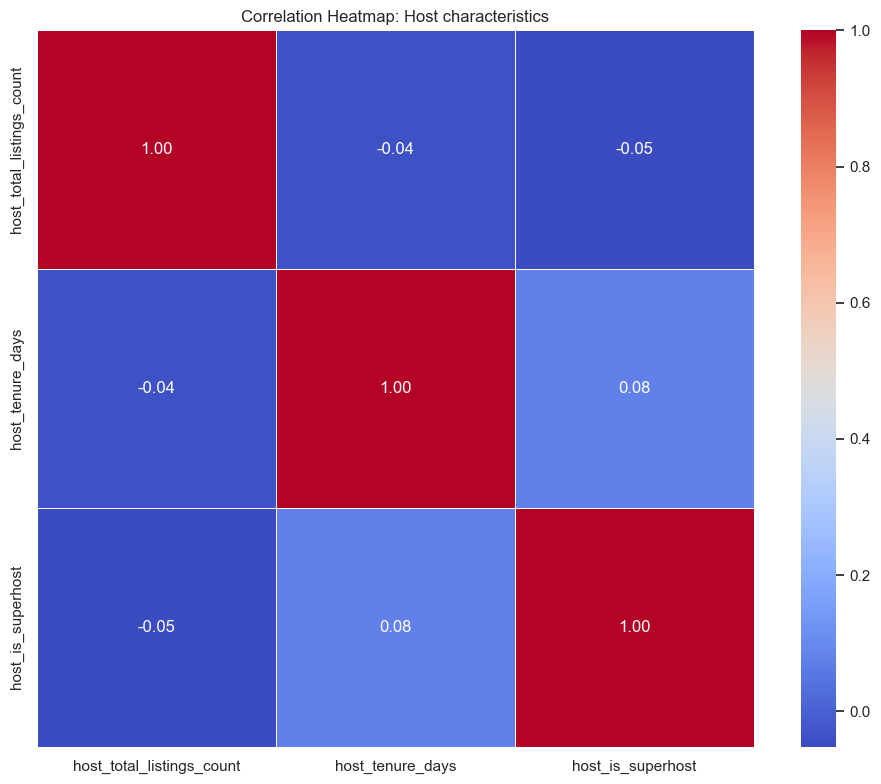

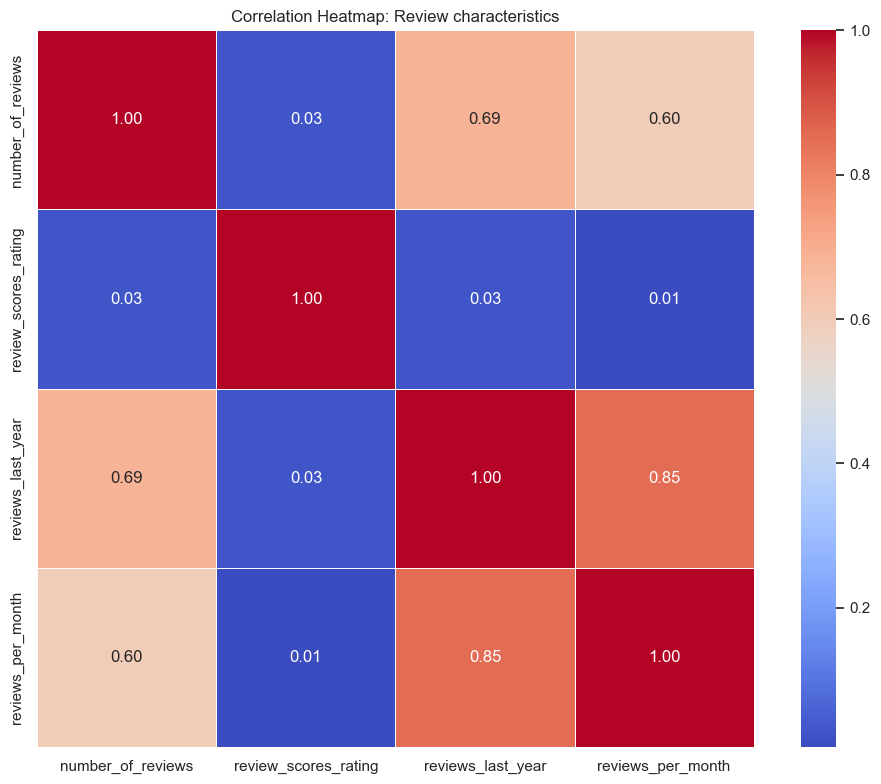

In [14]:
prop_params = ['price', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'instant_bookable', 'occupancy', 'accommodates', 'room_type_Entire home/apt', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room'] 


# add dummies for room type
prop_type_dummies = pd.get_dummies(df['room_type'], prefix='room_type', dtype=int)
# add dummies to the main dataframe
df = pd.concat([df, prop_type_dummies], axis=1)

# parameters of host characteristics
host_params = ['host_total_listings_count', 'host_tenure_days', 'host_is_superhost']

# parameters of reviews characteristics
reviews_params = ['number_of_reviews', 'review_scores_rating', 'reviews_last_year', 'reviews_per_month']


groups = {
    "Property characteristics": prop_params,
    "Host characteristics": host_params,
    "Review characteristics": reviews_params,
}

for group_name, params in groups.items():
    existing_params = [col for col in params if col in df.columns]

    corr_matrix = df[existing_params].corr(numeric_only=True)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap="coolwarm",
        fmt=".2f",
        linewidths=0.5,
        square=True
    )

    plt.title(f"Correlation Heatmap: {group_name}")
    plt.tight_layout()
    plt.show()

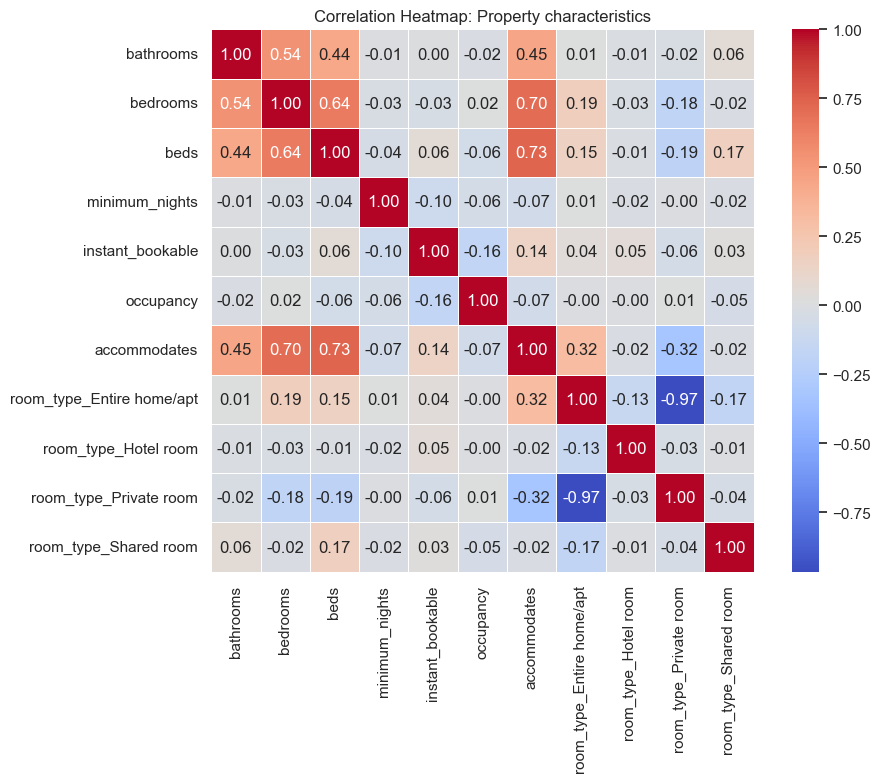

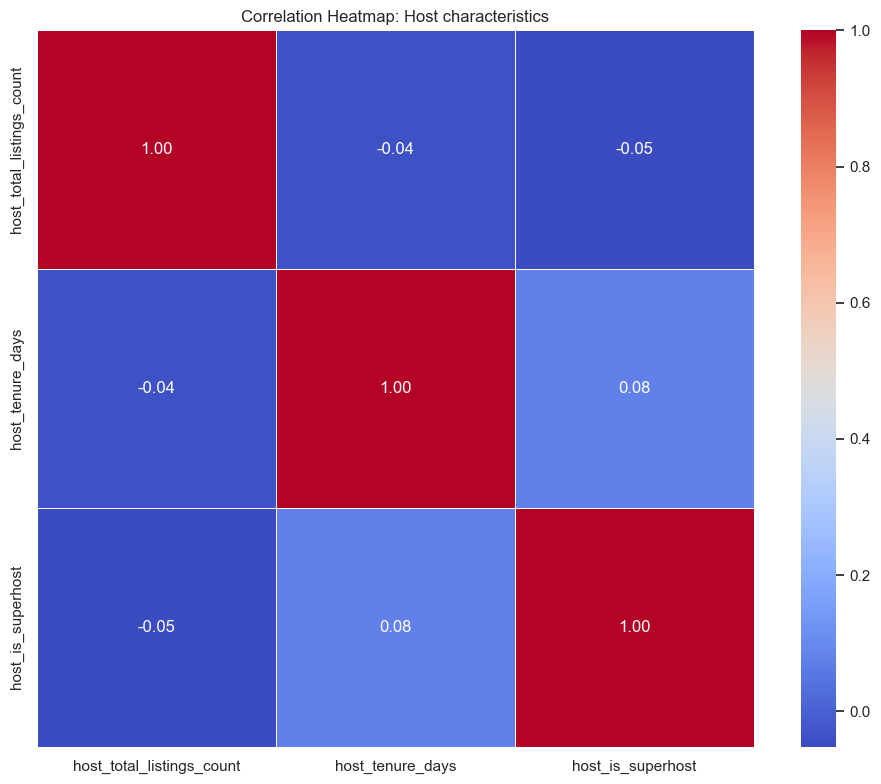

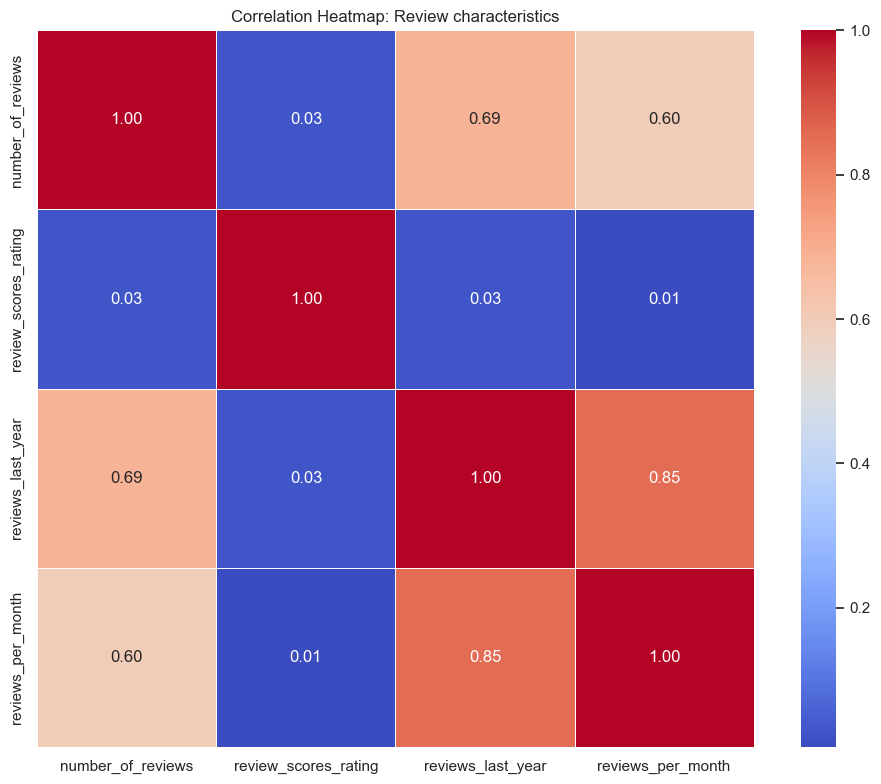

In [15]:

# df['instant_bookable'] = pd.to_numeric(df['instant_bookable'], errors='coerce')
room_type_params = ['room_type_Entire home/apt', 'room_type_Hotel room', 'room_type_Private room', 'room_type_Shared room']
prop_params = ['bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'instant_bookable', 'occupancy', 'accommodates'] 
prop_params += room_type_params

# parameters of host characteristics
host_params = ['host_total_listings_count', 'host_tenure_days', 'host_is_superhost']

# parameters of reviews characteristics
reviews_params = ['number_of_reviews', 'review_scores_rating', 'reviews_last_year', 'reviews_per_month']


groups = {
    "Property characteristics": prop_params,
    "Host characteristics": host_params,
    "Review characteristics": reviews_params,
}

for group_name, params in groups.items():
    existing_params = [col for col in params if col in df.columns]

    corr_matrix = df[existing_params].corr(numeric_only=True)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap="coolwarm",
        fmt=".2f",
        linewidths=0.5,
        square=True
    )

    plt.title(f"Correlation Heatmap: {group_name}")
    plt.tight_layout()
    plt.show()

## Correlation pairs

In [16]:
pairs = {
    "Price & Occupancy": ['price', 'occupancy'],
    "Distance to center & Price": ['distance_to_city_center', 'price'],
    "Reviews/month & Occupancy": ['reviews_per_month', 'occupancy']
}

results = []

for name, cols in pairs.items():
    temp = df[cols].dropna()
    corr = temp.corr().iloc[0,1]
    
    results.append({
        'Pair': name,
        'Correlation': round(corr, 3)
    })

pd.DataFrame(results)


,Pair,Correlation
0,Price & Occupancy,0.118
1,Distance to center & Price,-0.204
2,Reviews/month & Occupancy,-0.047


# Creating linear models and working with assumptions

## Models for price

In [17]:
y = df['price']
cols = ["host_is_superhost", "host_total_listings_count", "host_tenure_days", "accommodates", "bathrooms", "bedrooms", "beds", "availability_365", "number_of_reviews","reviews_last_year", "review_scores_rating", "reviews_per_month", "occupancy"]
X = df[cols].copy()
X = sm.add_constant(X)

price_linlin_model = sm.OLS(y, X).fit(cov_type='HC3')
price_loglin_model = sm.OLS(np.log1p(y), X).fit(cov_type='HC3')
price_linlog_model = sm.OLS(y, np.log1p(X)).fit(cov_type='HC3')
price_loglog_model = sm.OLS(np.log1p(y), np.log1p(X)).fit(cov_type='HC3')

In [18]:
print(price_linlin_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     31.04
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           9.59e-77
Time:                        15:59:42   Log-Likelihood:                -90930.
No. Observations:               11794   AIC:                         1.819e+05
Df Residuals:                   11780   BIC:                         1.820e+05
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [19]:
print(price_linlog_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     35.12
Date:                Sun, 26 Apr 2026   Prob (F-statistic):           1.49e-87
Time:                        15:59:42   Log-Likelihood:                -90930.
No. Observations:               11794   AIC:                         1.819e+05
Df Residuals:                   11780   BIC:                         1.820e+05
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [20]:
print(price_loglin_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.058
Model:                            OLS   Adj. R-squared:                  0.057
Method:                 Least Squares   F-statistic:                     64.25
Date:                Sun, 26 Apr 2026   Prob (F-statistic):          3.79e-164
Time:                        15:59:42   Log-Likelihood:                -18106.
No. Observations:               11794   AIC:                         3.624e+04
Df Residuals:                   11780   BIC:                         3.634e+04
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [21]:
print(price_loglog_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.058
Method:                 Least Squares   F-statistic:                     63.32
Date:                Sun, 26 Apr 2026   Prob (F-statistic):          9.86e-162
Time:                        15:59:42   Log-Likelihood:                -18098.
No. Observations:               11794   AIC:                         3.622e+04
Df Residuals:                   11780   BIC:                         3.633e+04
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [22]:
threshold = df['price'].median()
y = (df['price'] > threshold).astype(int)

X = df[cols].copy()
X = sm.add_constant(X)

price_probability_model = sm.OLS(y, X).fit(cov_type='HC3')
print(price_probability_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.077
Model:                            OLS   Adj. R-squared:                  0.076
Method:                 Least Squares   F-statistic:                     93.95
Date:                Sun, 26 Apr 2026   Prob (F-statistic):          1.91e-240
Time:                        15:59:42   Log-Likelihood:                -8089.8
No. Observations:               11794   AIC:                         1.621e+04
Df Residuals:                   11780   BIC:                         1.631e+04
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [23]:
price_logit_model = sm.Logit(y, X).fit(cov_type='HC3')
print(price_logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.651486
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                  price   No. Observations:                11794
Model:                          Logit   Df Residuals:                    11780
Method:                           MLE   Df Model:                           13
Date:                Sun, 26 Apr 2026   Pseudo R-squ.:                 0.06010
Time:                        15:59:42   Log-Likelihood:                -7683.6
converged:                       True   LL-Null:                       -8174.9
Covariance Type:                  HC3   LLR p-value:                9.648e-202
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -3.2264      0.915     -3.525      0.000      -5.

## Models for occupancy

In [24]:
y = df['occupancy']

cols = ["host_is_superhost", "host_total_listings_count", "host_tenure_days", "accommodates", "bathrooms", "bedrooms", "beds", "availability_365", "number_of_reviews","reviews_last_year", "review_scores_rating", "reviews_per_month", "price"]
X = df[cols].copy()
X = sm.add_constant(X)

occ_linlin_model = sm.OLS(y, X).fit(cov_type='HC3')
occ_loglin_model = sm.OLS(np.log1p(y), X).fit(cov_type='HC3')
occ_linlog_model = sm.OLS(y, np.log1p(X)).fit(cov_type='HC3')
occ_loglog_model = sm.OLS(np.log1p(y), np.log1p(X)).fit(cov_type='HC3')

In [25]:
print(occ_linlin_model.summary())

                            OLS Regression Results                            
Dep. Variable:              occupancy   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                 4.096e+06
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:59:42   Log-Likelihood:                 30432.
No. Observations:               11794   AIC:                        -6.084e+04
Df Residuals:                   11780   BIC:                        -6.073e+04
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [26]:
print(occ_linlog_model.summary())

                            OLS Regression Results                            
Dep. Variable:              occupancy   R-squared:                       0.746
Model:                            OLS   Adj. R-squared:                  0.746
Method:                 Least Squares   F-statistic:                     840.0
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:59:42   Log-Likelihood:                 4314.1
No. Observations:               11794   AIC:                            -8600.
Df Residuals:                   11780   BIC:                            -8497.
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [27]:
print(occ_loglin_model.summary())

                            OLS Regression Results                            
Dep. Variable:              occupancy   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.990
Method:                 Least Squares   F-statistic:                 7.561e+04
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:59:43   Log-Likelihood:                 27618.
No. Observations:               11794   AIC:                        -5.521e+04
Df Residuals:                   11780   BIC:                        -5.510e+04
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [28]:
print(occ_loglog_model.summary())

                            OLS Regression Results                            
Dep. Variable:              occupancy   R-squared:                       0.693
Model:                            OLS   Adj. R-squared:                  0.693
Method:                 Least Squares   F-statistic:                     728.3
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:59:43   Log-Likelihood:                 7462.5
No. Observations:               11794   AIC:                        -1.490e+04
Df Residuals:                   11780   BIC:                        -1.479e+04
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [29]:
threshold = df['occupancy'].median()
y = (df['occupancy'] > threshold).astype(int)

X = df[cols].copy()
X = sm.add_constant(X)

occ_probability_model = sm.OLS(y, X).fit(cov_type='HC3')
print(occ_probability_model.summary())

                            OLS Regression Results                            
Dep. Variable:              occupancy   R-squared:                       0.778
Model:                            OLS   Adj. R-squared:                  0.778
Method:                 Least Squares   F-statistic:                     7561.
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:59:43   Log-Likelihood:                 325.52
No. Observations:               11794   AIC:                            -623.0
Df Residuals:                   11780   BIC:                            -519.8
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [30]:
occ_logit_model = sm.Logit(y, X).fit(cov_type='HC3')
print(occ_logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.037050
         Iterations 13
                           Logit Regression Results                           
Dep. Variable:              occupancy   No. Observations:                11794
Model:                          Logit   Df Residuals:                    11780
Method:                           MLE   Df Model:                           13
Date:                Sun, 26 Apr 2026   Pseudo R-squ.:                  0.9465
Time:                        15:59:43   Log-Likelihood:                -436.97
converged:                       True   LL-Null:                       -8175.0
Covariance Type:                  HC3   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        43.6723     10.066      4.339      0.000      23

# Checking assumptions for models

## Heteroskedasticity

In [31]:
def heteroskedasticity_test(model):
    _, pval, _, _ = het_breuschpagan(model.resid, model.model.exog)
    print(f"p-value = {pval}")
    
    if pval < 0.05:
        print("Heteroskedasticity\n")
    else:
        print("Homoscedasticity\n")

In [32]:
heteroskedasticity_test(price_linlin_model)
heteroskedasticity_test(price_loglin_model)
heteroskedasticity_test(price_linlog_model)
heteroskedasticity_test(price_loglog_model)
heteroskedasticity_test(occ_linlin_model)
heteroskedasticity_test(occ_loglin_model)
heteroskedasticity_test(occ_linlog_model)
heteroskedasticity_test(occ_loglog_model)

p-value = 1.875405423696196e-42
Heteroskedasticity

p-value = 4.211051971336079e-81
Heteroskedasticity

p-value = 3.0146152282886345e-48
Heteroskedasticity

p-value = 2.651629945919668e-89
Heteroskedasticity

p-value = 0.001850127723169404
Heteroskedasticity

p-value = 0.005872466709342003
Heteroskedasticity

p-value = 0.0
Heteroskedasticity

p-value = 0.0
Heteroskedasticity



## Linearity

In [33]:
def linearity_test(model):
    _, pval = sm.stats.linear_rainbow(model)
    print(f"p-value = {pval}")
    
    if pval < 0.05:
        print("Bad linearity\n")
    else:
        print("Good linearity\n")

In [34]:
linearity_test(price_linlin_model)
linearity_test(price_loglin_model)
linearity_test(price_linlog_model)
linearity_test(price_loglog_model)
linearity_test(occ_linlin_model)
linearity_test(occ_loglin_model)
linearity_test(occ_linlog_model)
linearity_test(occ_loglog_model)
linearity_test(price_probability_model)
linearity_test(occ_probability_model)

p-value = 0.9999999999999999
Good linearity

p-value = 0.9999999999999999
Good linearity

p-value = 0.9999999999999999
Good linearity

p-value = 0.9999999999999999
Good linearity

p-value = 0.9999999999999999
Good linearity

p-value = 0.9999999999999999
Good linearity

p-value = 0.8970395158985821
Good linearity

p-value = 0.82834539622754
Good linearity

p-value = 0.06188277296668053
Good linearity

p-value = 0.9996833309668107
Good linearity



## Independance

In [35]:
def durbin_watson_test(model):
    dw_stat = durbin_watson(model.resid)
    print(f"DW = {dw_stat}")
    if dw_stat < 1.5:
        print("Positive\n")
    elif dw_stat > 2.5:
        print("Negative\n")
    else:
        print("No autocorrelation\n")

In [36]:
durbin_watson_test(price_linlin_model)
durbin_watson_test(price_loglin_model)
durbin_watson_test(price_linlog_model)
durbin_watson_test(price_loglog_model)
durbin_watson_test(occ_linlin_model)
durbin_watson_test(occ_loglin_model)
durbin_watson_test(occ_linlog_model)
durbin_watson_test(occ_loglog_model)
durbin_watson_test(price_probability_model)
durbin_watson_test(occ_probability_model)

DW = 0.5262952062042482
Positive

DW = 0.5208426467691217
Positive

DW = 0.530461611033177
Positive

DW = 0.5305866269138241
Positive

DW = 2.003188417314704
No autocorrelation

DW = 2.0043023088402316
No autocorrelation

DW = 1.9790318417861648
No autocorrelation

DW = 1.9804184352550425
No autocorrelation

DW = 1.1086515780287223
Positive

DW = 2.029652848426892
No autocorrelation



## Normality

In [37]:
def jarque_bera_test(model):
    jb_stat, jb_pval, _, _ = sm.stats.jarque_bera(model.resid)
    print(f"JB = {jb_stat}, p-value = {jb_pval}")
    
    if jb_pval < 0.05:
        print("Non-normality\n")
    else:
        print("Normality\n")

In [38]:
jarque_bera_test(price_linlin_model)
jarque_bera_test(price_loglin_model)
jarque_bera_test(price_linlog_model)
jarque_bera_test(price_loglog_model)
jarque_bera_test(occ_linlin_model)
jarque_bera_test(occ_loglin_model)
jarque_bera_test(occ_linlog_model)
jarque_bera_test(occ_loglog_model)

JB = 6581.915089446119, p-value = 0.0
Non-normality

JB = 868.711761926824, p-value = 2.2995227754296136e-189
Non-normality

JB = 6576.24208824993, p-value = 0.0
Non-normality

JB = 877.9013415941583, p-value = 2.3235169505534398e-191
Non-normality

JB = 2321066627.961965, p-value = 0.0
Non-normality

JB = 20662130.309258036, p-value = 0.0
Non-normality

JB = 4434.713363906762, p-value = 0.0
Non-normality

JB = 1388.5104888646247, p-value = 3.0816145121138254e-302
Non-normality



## Assumptions for logit model

In [39]:
print(price_logit_model.summary())

                           Logit Regression Results                           
Dep. Variable:                  price   No. Observations:                11794
Model:                          Logit   Df Residuals:                    11780
Method:                           MLE   Df Model:                           13
Date:                Sun, 26 Apr 2026   Pseudo R-squ.:                 0.06010
Time:                        15:59:43   Log-Likelihood:                -7683.6
converged:                       True   LL-Null:                       -8174.9
Covariance Type:                  HC3   LLR p-value:                9.648e-202
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -3.2264      0.915     -3.525      0.000      -5.020      -1.432
host_is_superhost            -0.3759      0.045     -8.321      0.000      -0.464     

In [40]:
print(occ_logit_model.summary())

                           Logit Regression Results                           
Dep. Variable:              occupancy   No. Observations:                11794
Model:                          Logit   Df Residuals:                    11780
Method:                           MLE   Df Model:                           13
Date:                Sun, 26 Apr 2026   Pseudo R-squ.:                  0.9465
Time:                        15:59:43   Log-Likelihood:                -436.97
converged:                       True   LL-Null:                       -8175.0
Covariance Type:                  HC3   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        43.6723     10.066      4.339      0.000      23.944      63.401
host_is_superhost             0.0697      0.126      0.555      0.579      -0.176     

### Model significance

In [41]:
price_pval = price_logit_model.llr_pvalue
occ_pval = occ_logit_model.llr_pvalue

alpha = 0.05
def significance_test(pval, model_name):
    if pval < alpha:
        print(f"{model_name}: Model is significant, p-value = {pval}")
    else:
        print(f"{model_name}: Model is not significant, p-value = {pval}")

significance_test(price_pval, "PRICE model")
significance_test(occ_pval, "OCC model")

PRICE model: Model is significant, p-value = 9.648454005002126e-202
OCC model: Model is significant, p-value = 0.0


### Pseudo $R^2$

In [42]:
price_r2 = price_logit_model.prsquared
occ_r2 = occ_logit_model.prsquared

def interpret_r2(r2, model_name):
    if r2 < 0.2:
        quality = "weak"
    elif r2 < 0.4:
        quality = "moderate"
    else:
        quality = "strong"

    print(f"{model_name}: quality of model — {quality} (Pseudo R² = {r2:.3f})")

interpret_r2(price_r2, "PRICE model")
interpret_r2(occ_r2, "OCC model")

PRICE model: quality of model — weak (Pseudo R² = 0.060)
OCC model: quality of model — strong (Pseudo R² = 0.947)


In [43]:
# df["instant_bookable"] = df["instant_bookable"].fillna("f")
# df["instant_bookable"] = df["instant_bookable"].map({'t': 1, 'f': 0})

In [44]:
# df = df[df['price'] != 185.0]

In [45]:

room_type_params = list(prop_type_dummies.columns)[:-1]

# add dummies for cities
city_dummies = pd.get_dummies(df['city'], prefix='city', dtype=int)
df = pd.concat([df, city_dummies], axis=1)
city_params = list(city_dummies.columns)[:-1]

df = df.loc[:, ~df.columns.duplicated()]

In [46]:
# test the joint significance of cities on log price
X_cities = df[city_params]
X_cities = sm.add_constant(X_cities)
model_cities = sm.OLS(df['log_price'], X_cities).fit()
print(model_cities.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.747
Model:                            OLS   Adj. R-squared:                  0.747
Method:                 Least Squares   F-statistic:                     4346.
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:59:43   Log-Likelihood:                -10357.
No. Observations:               11794   AIC:                         2.073e+04
Df Residuals:                   11785   BIC:                         2.080e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               4.6044      0.015    3

In [47]:
# introduce variable log_delta_price that corresponds to the difference between log price and log of median price in the city
median_log_price_by_city = df.groupby('city')['log_price'].transform('median')
df['log_delta_price'] = df['log_price'] - median_log_price_by_city

In [48]:
# build model for log_delta_price with all parameters 

X = df[prop_params + host_params + reviews_params + loc_params]
X = sm.add_constant(X)
model = sm.OLS(df['log_delta_price'], X).fit()
print(model.summary())

NameError: name 'loc_params' is not defined

In [ ]:
aic = {}
y = df["log_delta_price"]
params = prop_params + host_params + reviews_params + loc_params
eliminated_vars = []
while True:
    x = df[params]
    x = sm.add_constant(x)
    model_current = sm.OLS(y, x).fit()
    aic["baseline"] =  model_current.aic
    for col in df[params]:
        y = df["log_delta_price"]
        candidate_params = params.copy()
        candidate_params.remove(col)
        x = df[candidate_params]
        x = sm.add_constant(x)
        model_cand = sm.OLS(y, x).fit()
        aic[col] = model_cand.aic

    aic_sorted = dict(sorted(aic.items(), key=lambda item: item[1]))
    best_var_to_remove = list(aic_sorted.keys())[0]
    best_aic = aic_sorted[best_var_to_remove]
    current_aic = aic_sorted["baseline"]
    if best_aic < current_aic:
        params.remove(best_var_to_remove)
        eliminated_vars.append({
                'excluded_variable': best_var_to_remove,
                'p_value_at_excluding': model_current.pvalues[best_var_to_remove],
                'AIC_before': current_aic,
                'AIC_after': best_aic
            })
    else:
        break

result_df = pd.DataFrame(eliminated_vars)

result_df


In [ ]:
model = sm.OLS(df['log_delta_price'], sm.add_constant(df[params])).fit()
print(model.summary())

In [ ]:
par = params.copy()
# par.remove('number_of_reviews')
# par.remove('host_tenure_days')

In [ ]:
model = sm.OLS(df['log_delta_price'], sm.add_constant(df[par])).fit()
print(model.summary())


In [ ]:
heteroskedasticity_test(model)
linearity_test(model)
durbin_watson_test(model)
jarque_bera_test(model)